# Switch-Bounded Load Blocks

**Infrastructure Step 4.** Apply the Block Invariant Contract (Moring et al. 2025 II-A, II-B) to the partition induced by opening all Controllable Switches and emit
`switch_bounded_load_blocks.parquet`.

Each block must pass:
- **(B)** non-empty in load or substation PCC
- **(C)** confined to a single Bus Voltage Class
- **(D/E)** records `phi_max` and the union of per-bus phase sets
- **(F)** acyclic in the static line graph with all Controllable Switches open
- **(G)** records Block Voltage Source Reachability (`substation_pcc`, `gfm_eligible_der`,
  `both`, `pending_der_inventory`, or `none`)

B/C/D/E/F are hard failures. G is recorded and may return `pending_der_inventory` until
`der_inventory.parquet` is complete.

Reference: `docs/power/reference/moring_2025_networked_microgrids_load_uncertainty.pdf`

> **Stage Contract**
>
> Requires: controllable switches, loads, sources, transformers, topology
>
> Produces: switch_bounded_load_blocks.parquet and invariant report
>
> Next: 05_onm_export.ipynb

## Runtime

In [1]:
import os
from pathlib import Path
import sys

import pandas as pd
from IPython.display import display

repo_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
sys.path.insert(0, str(repo_root / "src"))

from sfincs_runs.config import load_runtime, build_grid_paths

location_name = os.environ.get("FLOOD_RM_LOCATION", "marshfield")
config_yaml = Path(os.environ.get("FLOOD_RM_LOCATION_CONFIG", repo_root / "locations" / location_name / "config.yaml")).expanduser()
config, paths = load_runtime(config_yaml)
grid = build_grid_paths(config)

grid["augmented_artifacts"].mkdir(parents=True, exist_ok=True)

## Load Prerequisites

In [2]:
buses = pd.read_csv(grid["asset_registry"] / "buses.csv")
lines = pd.read_csv(grid["asset_registry"] / "lines.csv")
loads = pd.read_csv(grid["asset_registry"] / "loads.csv")
sources = pd.read_csv(grid["asset_registry"] / "sources.csv")
transformers = pd.read_csv(grid["asset_registry"] / "transformers.csv")
switches = pd.read_parquet(grid["augmented_artifacts"] / "controllable_switches.parquet")
der_inventory = pd.read_parquet(grid["augmented_artifacts"] / "der_inventory.parquet")
print(f"{len(switches)} switches, {len(der_inventory)} DER rows, {len(transformers)} transformers")

150 switches, 15 DER rows, 877 transformers


## Validate Block Invariant Contract

Open all switches and partition the network into blocks. Hard-fail on B/C/D/E/F
violations; record G with a `pending_der_inventory` status when DER assignment
is incomplete.

In [3]:
from power.resilience import build_switch_bounded_load_blocks

blocks, validation_report = build_switch_bounded_load_blocks(
    buses=buses,
    lines=lines,
    loads=loads,
    sources=sources,
    switches=switches,
    der_inventory=der_inventory,
    transformers=transformers,
    sandbox_id=paths["location_name"],
)

print(f"Blocks: {len(blocks)}")
print(f"Invariant violations: {validation_report.get('violations', [])}")
display(pd.Series(validation_report.get("summary", {}), name="block_invariant_summary"))

Blocks: 192
Invariant violations: []


block_count                                                                  192
total_load_kw                                                            47190.0
max_bus_count                                                                314
voltage_source_reachability    {'both': 5, 'gfm_eligible_der': 7, 'none': 143...
Name: block_invariant_summary, dtype: object

## Block Voltage Source Reachability Summary

In [4]:
# Distribution of Block Voltage Source Reachability across all blocks.
display(blocks["voltage_source_reachability"].value_counts().rename("block_count"))

voltage_source_reachability
none                143
substation_pcc       37
gfm_eligible_der      7
both                  5
Name: block_count, dtype: int64

## Write Artifact

In [5]:
import json

out_path = grid["augmented_artifacts"] / "switch_bounded_load_blocks.parquet"
blocks.to_parquet(out_path, index=False)

report_path = grid["augmented_artifacts"] / "block_invariant_report.json"
report_path.write_text(json.dumps(validation_report, indent=2))

print(f"Wrote {len(blocks)} blocks to {out_path.relative_to(repo_root)}")
print(f"Validation report: {report_path.relative_to(repo_root)}")

Wrote 192 blocks to locations/marshfield/data/static/power_grid/smart_ds_compat/switch_bounded_load_blocks.parquet
Validation report: locations/marshfield/data/static/power_grid/smart_ds_compat/block_invariant_report.json


## Plot Block Review Figures

Render the full switch-bounded block hull plot and the Ocean Bluff / Brant Rock detailed plot using the same visual grammar as the working `projects/dft` figures.


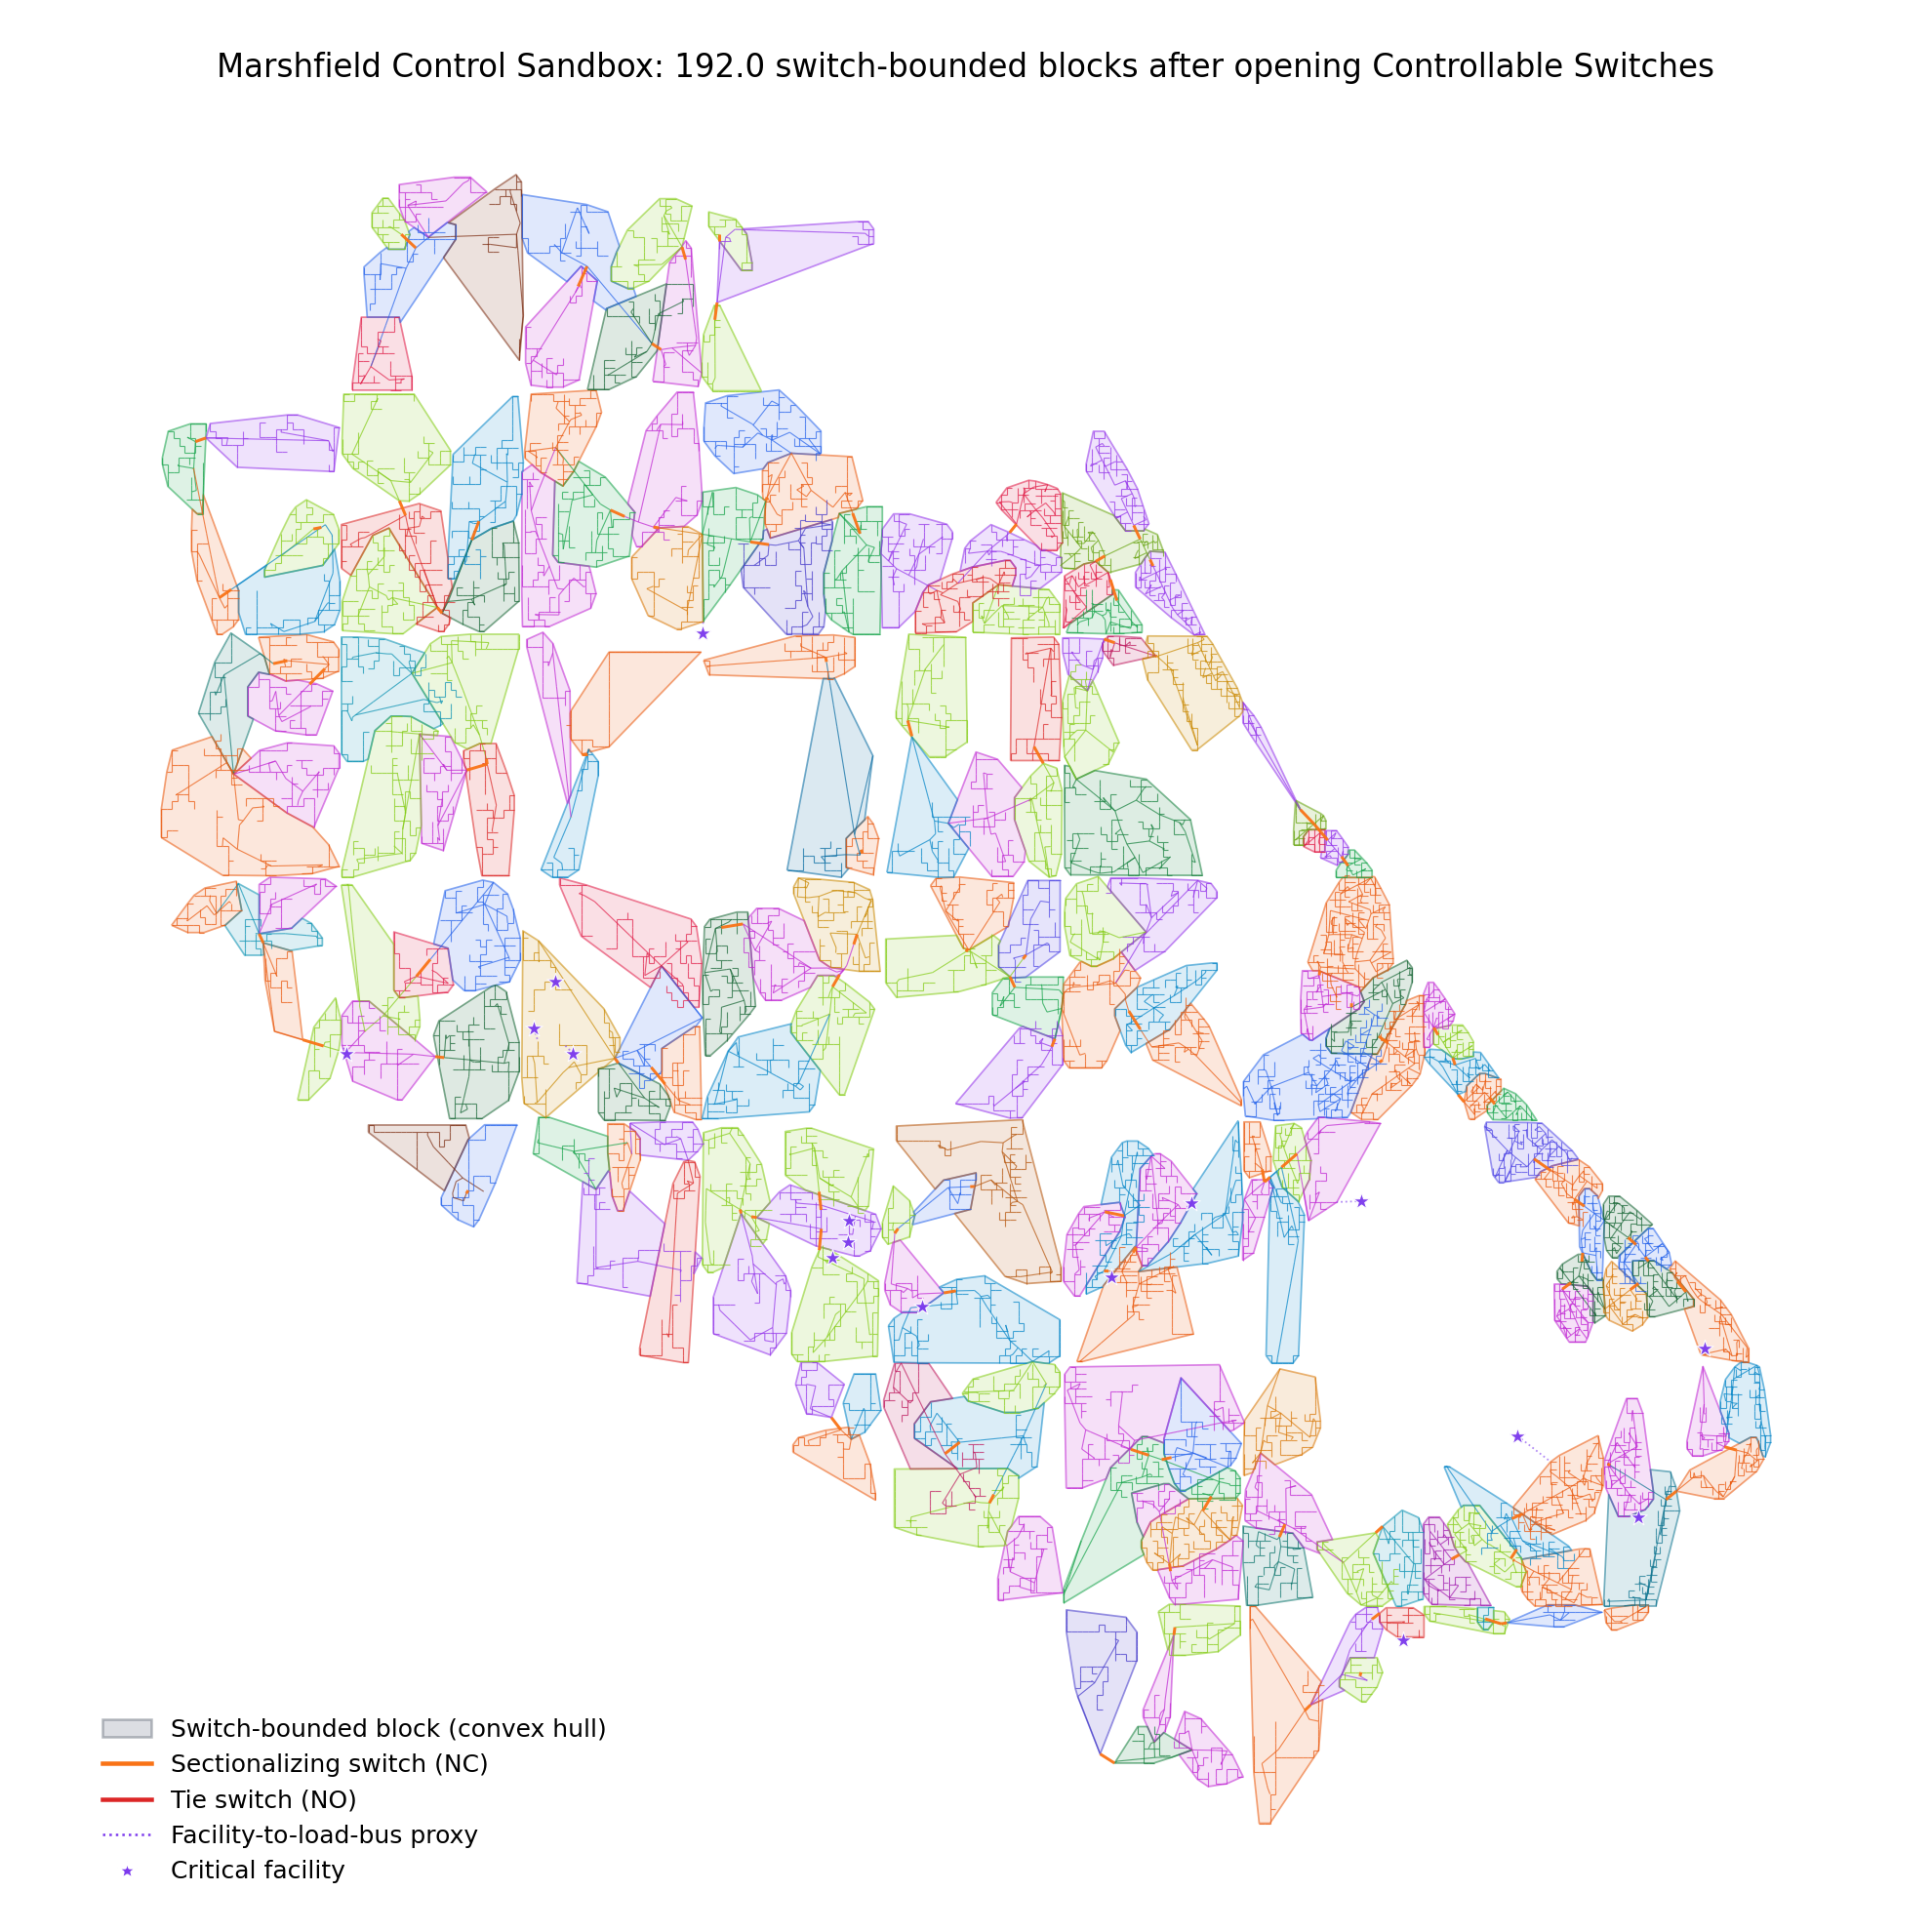

output_path                         /home/grahamhults/projects/Flood-RM/locations/...
switch_bounded_blocks                                                             192
opened_existing_lines_for_blocks                                                  150
median_block_bus_count                                                           81.5
max_block_bus_count                                                               314
display_block_hulls                                                               192
block_line_segments                                                             15837
sectionalizing_switch_segments                                                    150
tie_switch_segments                                                                 0
zero_length_tie_ticks                                                               0
critical_facility_segments                                                         16
Name: location_block_overview, dtype: object

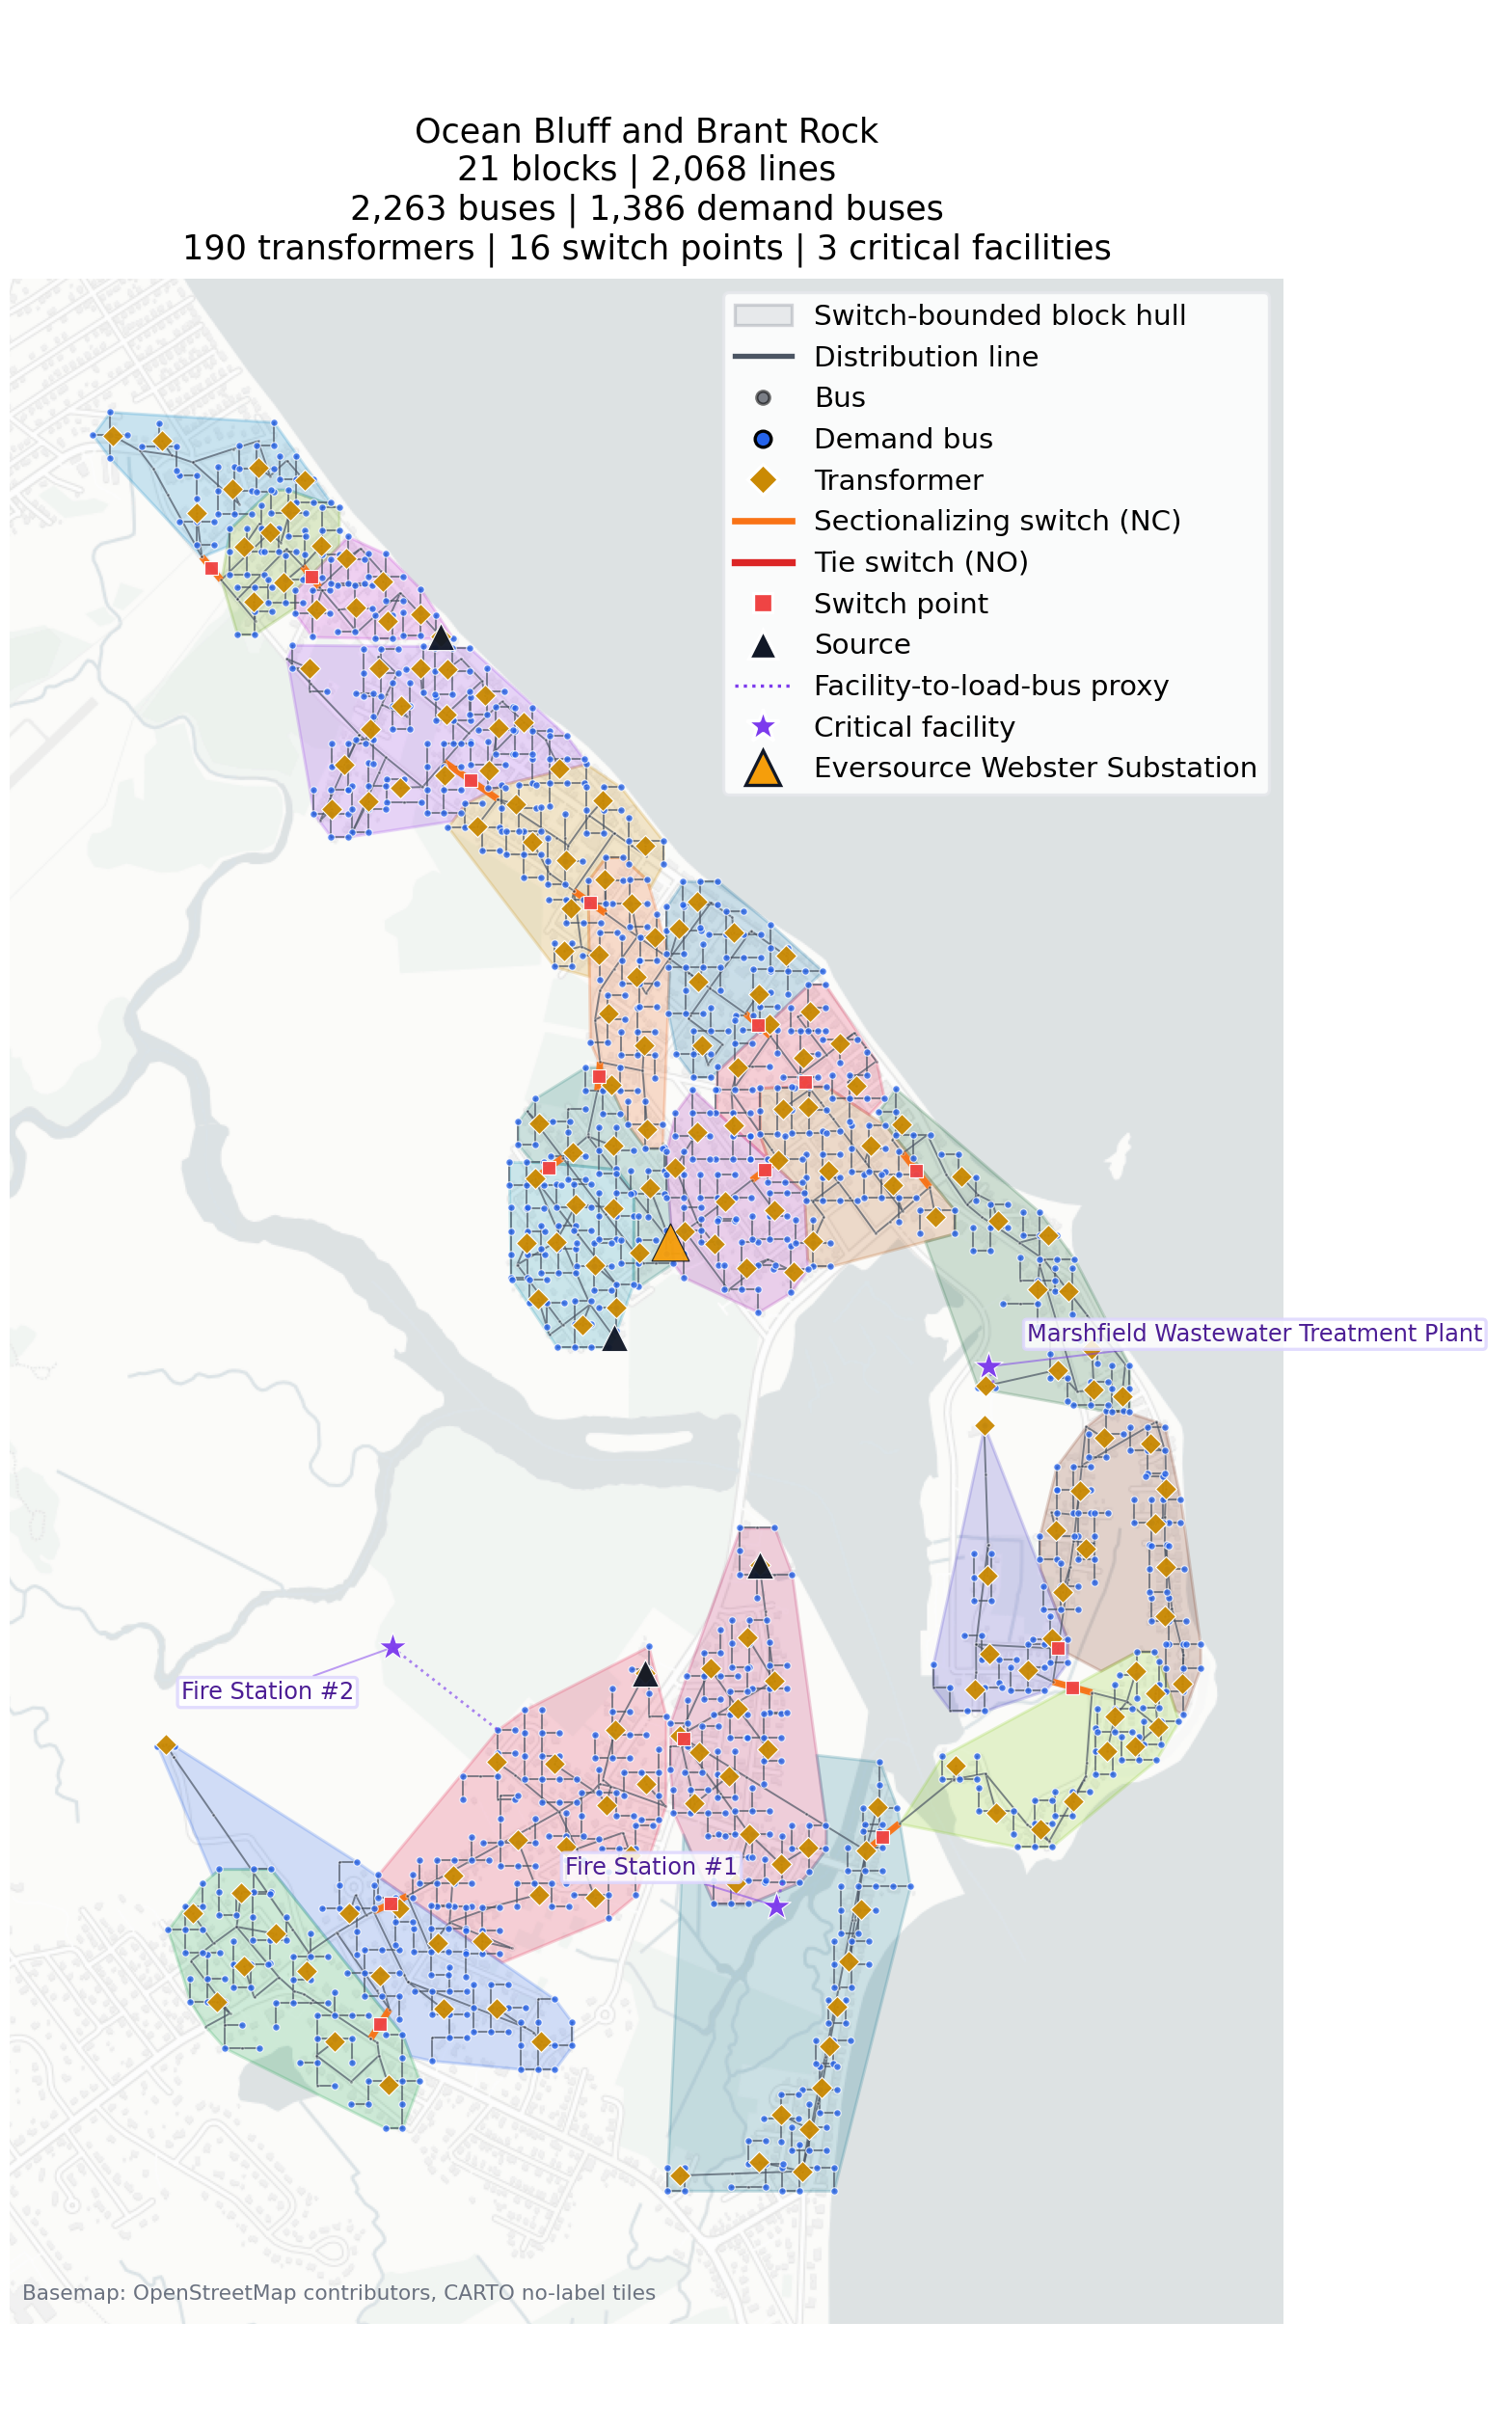

output_path                             /home/grahamhults/projects/Flood-RM/locations/...
selected_block_bus_members                                                           2263
local_lines                                                                          2068
local_buses                                                                          2263
local_demand_buses                                                                   1386
local_transformers                                                                    190
local_sources                                                                           5
local_switch_markers                                                                   16
local_sectionalizing_switch_segments                                                   16
local_tie_switch_segments                                                               0
visible_block_hulls                                                                    21
critical_f

In [6]:
from IPython.display import Image, display

from power.plotting import (
    build_location_block_overview,
    build_ocean_bluff_block_detail,
)

block_overview = build_location_block_overview(
    registry_dir=grid["asset_registry"],
    smart_ds_compat_dir=grid["augmented_artifacts"],
    output_path=grid["figures"] / "switch_bounded_blocks.png",
)
ocean_bluff_detail = build_ocean_bluff_block_detail(
    registry_dir=grid["asset_registry"],
    smart_ds_compat_dir=grid["augmented_artifacts"],
    output_path=grid["figures"] / "ocean_bluff" / "ocean_bluff_network_components.png",
)

display(Image(filename=block_overview["output_path"]))
display(pd.Series(block_overview, name="location_block_overview"))
display(Image(filename=ocean_bluff_detail["output_path"]))
display(pd.Series(ocean_bluff_detail, name="ocean_bluff_detail"))
